In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
def log_preprocessing(root_path):
    log_path = os.path.join(root_path, "download.txt")
    with open(log_path) as file:
        content = file.readlines()
    content = [log for log in content if "Loss" in log]
    logs = []

    for i in range(len(content)):
        epoch = content[i].split('│')
        loss = epoch[1].split('/')
        train_loss = float(loss[0][7:-1])
        val_loss = float(loss[1][1:-1])
        acc = float(epoch[2][-7:-1])
        f1 = float(epoch[3][-7:-1])
        k = float(epoch[4][-7:-1])
        mcc = float(epoch[5][-7:-1])
        lr = float(epoch[6][-9:-1])
        time = float(epoch[7][1:-4])
        logs.append([i+1, train_loss, val_loss, acc, f1, k, mcc, lr, time])

    columns = ["epoch", "train_loss", "val_loss", "acc", "f1", "k", "mcc", "lr", "time"]

    save_path = os.path.join(root_path, "log.csv")
    df = pd.DataFrame(logs, columns=columns)
    df.to_csv(save_path, index=False)

In [15]:
sca_edge = pd.read_csv(r"D:\Capstone\models\PT\CNN_LATEST\SCALOGRAM\EdgeNeXTXXS\log.csv")
sca_ghost = pd.read_csv(r"D:\Capstone\models\PT\CNN_LATEST\SCALOGRAM\GhostNetV3\log.csv")
sca_mobile = pd.read_csv(r"D:\Capstone\models\PT\CNN_LATEST\SCALOGRAM\MobileNetV4\log.csv")
sca_mobile_ = pd.read_csv(r"D:\Capstone\models\PT\CNN_LATEST\SCALOGRAM\MobileOneS0\log.csv")

spe_edge = pd.read_csv(r"D:\Capstone\models\PT\CNN_LATEST\SPECTROGRAM\EdgeNeXTXXS\log.csv")
spe_ghost = pd.read_csv(r"D:\Capstone\models\PT\CNN_LATEST\SPECTROGRAM\GhostNetV3\log.csv")
spe_mobile = pd.read_csv(r"D:\Capstone\models\PT\CNN_LATEST\SPECTROGRAM\MobileNetV4\log.csv")
spe_mobile_ = pd.read_csv(r"D:\Capstone\models\PT\CNN_LATEST\SPECTROGRAM\MobileOneS0\log.csv")

In [16]:
sca_models = {
    "EdgeNeXTXXS": sca_edge,
    "GhostNetV3": sca_ghost,
    "MobileNetV4": sca_mobile,
    "MobileOneS0": sca_mobile_
}

spe_models = {
    "EdgeNeXTXXS": spe_edge,
    "GhostNetV3": spe_ghost,
    "MobileNetV4": spe_mobile,
    "MobileOneS0": spe_mobile_
}

metrics = ['train_loss', 'val_loss', 'acc', 'f1', 'k', 'mcc', 'lr', 'time']

In [24]:
def plot_2x4_like_image(models_dict, title):
    import matplotlib.pyplot as plt

    # Reset to default matplotlib style (matches your image)
    plt.rcParams.update(plt.rcParamsDefault)

    fig, axes = plt.subplots(2, 4, figsize=(20, 8))  # taller than your version
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]

        for name, df in models_dict.items():
            ax.plot(
                df['epoch'],
                df[metric],
                linewidth=2,   # thicker lines like image
                label=name
            )

        # Titles and labels (shown on ALL plots)
        ax.set_title(metric)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric)

        # Grid similar to image
        ax.grid(True, linestyle='-', alpha=0.3)

        # Normalize metrics
        if metric in ['acc', 'f1', 'k', 'mcc']:
            ax.set_ylim(0, 1)

    # Legend centered at bottom (inside figure area)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc='lower center',
        ncol=4
    )

    # Title
    fig.suptitle(title, fontsize=14)

    # Layout spacing similar to image
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])

    plt.show()

In [ ]:
def plot_2x4_ieee(models_dict, title):
    # IEEE-like styling
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "legend.fontsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "lines.linewidth": 1.5
    })

    fig, axes = plt.subplots(2, 4, figsize=(20, 5))
    axes = axes.flatten()

    # Grayscale-friendly styles
    linestyles = ['-', '--', '-.', ':']
    markers = ['o', 's', '^', 'D']

    for i, metric in enumerate(metrics):
        ax = axes[i]

        for j, (name, df) in enumerate(models_dict.items()):
            ax.plot(
                df['epoch'],
                df[metric],
                linestyle=linestyles[j],
                marker=markers[j],
                markevery=3,   # avoid clutter
                markersize=4,
                label=name
            )

        # Titles & labels
        ax.set_title(metric)

        # Only show outer labels (clean layout)
        if i // 4 == 1:
            ax.set_xlabel("Epoch")
        if i % 4 == 0:
            ax.set_ylabel(metric)

        # Light grid (IEEE style)
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

        # Optional: normalize axis ranges
        if metric in ['acc', 'f1', 'k', 'mcc']:
            ax.set_ylim(0, 1)

    # Shared legend at bottom
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc='lower center',
        ncol=4,
        frameon=False
    )

    # Title
    fig.suptitle(title, fontsize=12)

    # Tight layout (important)
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])

    plt.show()

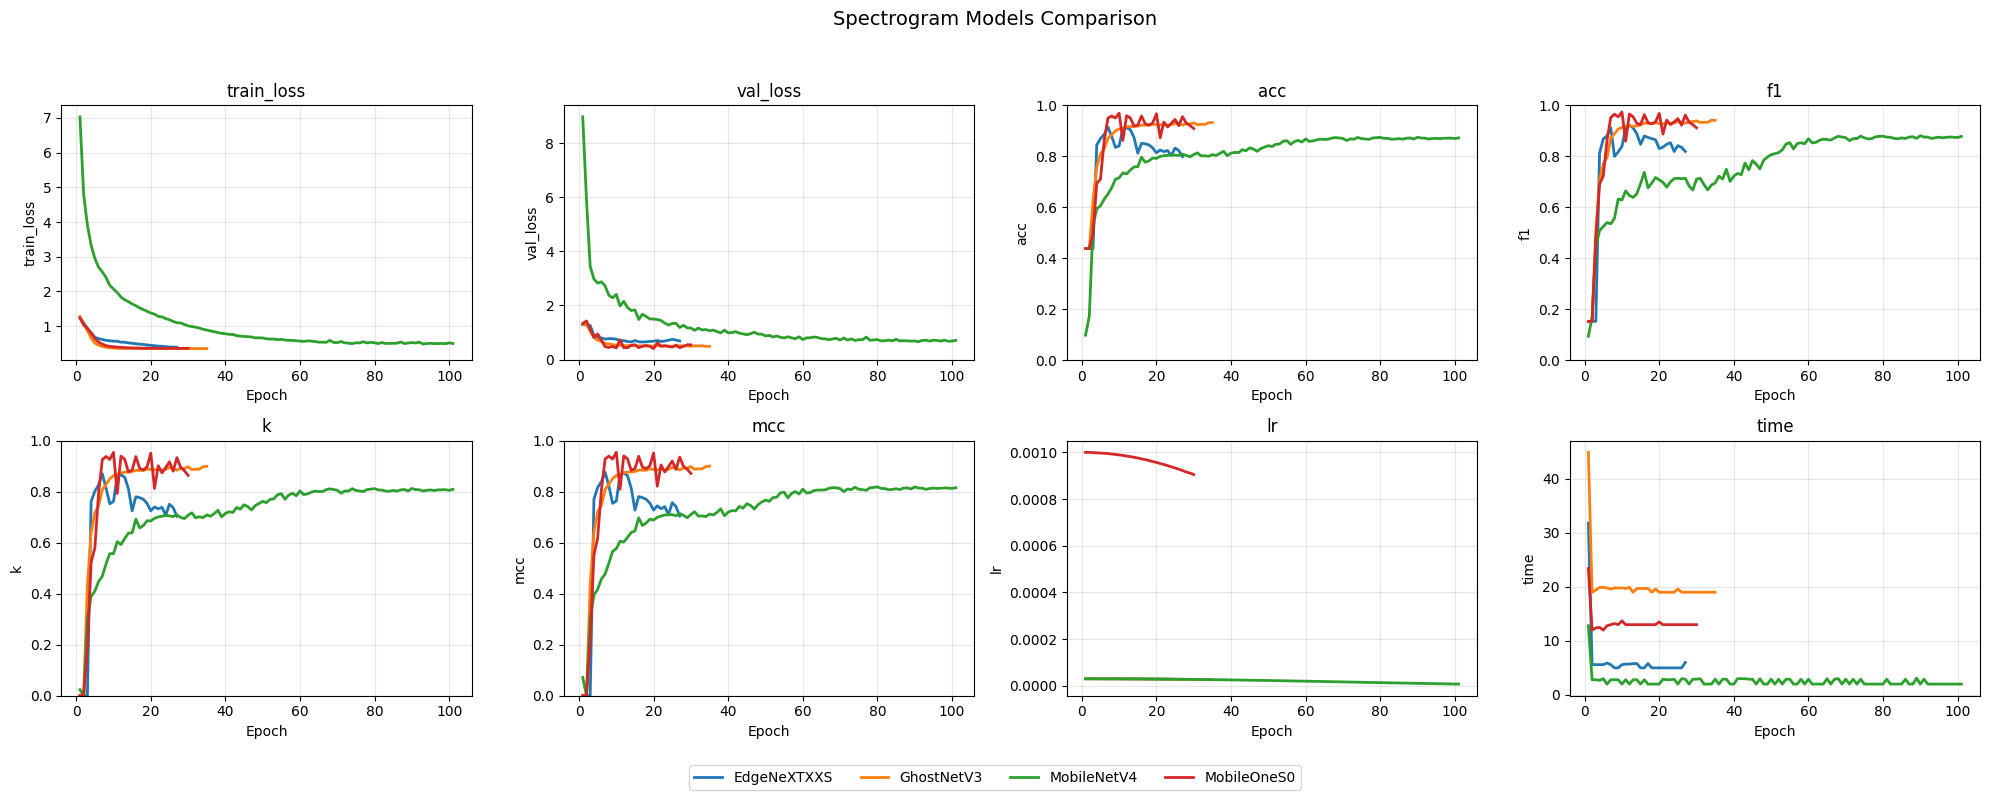

In [26]:
plot_2x4_like_image(spe_models, "Spectrogram Models Comparison")